In [217]:
import torch.nn as nn
import torch.nn.functional as F

class PerturbationGeneratorNet(nn.Module):
    """
    A network that learns to generate an instance-specific perturbation (delta)
    for a given input X.
    """
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input_dim) # Output dimension MUST match input
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The output is the instance-specific perturbation vector 'delta'
        return self.net(x)

In [218]:
from sklearn.metrics import mean_squared_log_error
from typing import Optional, Callable

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

DATA_TRAIN_PATH = "../data/train.csv"
DATA_TEST_PATH = "../data/test.csv"
target_col = "count"

def read_data(path):
    df = pd.read_csv(path, parse_dates=["datetime"])

    season = pd.get_dummies(df['season'], prefix='season')
    df = pd.concat([df, season], axis=1)

    weather = pd.get_dummies(df['weather'], prefix='weather')
    df = pd.concat([df, weather], axis=1)

    df.drop(['season', 'weather'], axis=1, inplace=True)

    dt_index = pd.DatetimeIndex(df.datetime)
    df['hour'] = dt_index.hour
    df['day'] = dt_index.dayofweek
    df['month'] = dt_index.month
    df['year'] = dt_index.year.map({2011: 0, 2012: 1})

    df.drop('datetime', axis=1, inplace=True)

    # Drop train-only columns if present
    drop_cols = [c for c in ['casual', 'registered'] if c in df.columns]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)

    return df

train_df = read_data(DATA_TRAIN_PATH)
test_df = read_data(DATA_TEST_PATH)

feature_cols = [c for c in train_df.columns if c != target_col and c in test_df.columns]
print(f"Feature count: {len(feature_cols)}")

scaler = StandardScaler()
train_features = scaler.fit_transform(train_df[feature_cols].values.astype(np.float32))
train_target = train_df[target_col].values.astype(np.float32)


def build_lag_supervised(features, target, context_length):
    X_list, y_list = [], []
    for i in range(len(target) - context_length):
        X_window = features[i:i + context_length].reshape(-1)
        y_val = target[i + context_length]
        X_list.append(X_window)
        y_list.append(y_val)
    return np.vstack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32)


context_length = 24
X_all, y_all = build_lag_supervised(train_features, train_target, context_length)
print("Supervised shape:", X_all.shape, y_all.shape)

# Train / holdout split (time-ordered)
train_ratio = 0.8
n_train = int(len(X_all) * train_ratio)
X_model, X_test_hold = X_all[:n_train], X_all[n_train:]
y_model, y_test_hold = y_all[:n_train], y_all[n_train:]
print("Train segment:", X_model.shape, "Test segment:", X_test_hold.shape)

# Train / validation for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_model, y_model, test_size=0.15, shuffle=False)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1.0,
    "gamma": 0.0,
    "min_child_weight": 1
}

evals = [(dtrain, "train"), (dval, "val")]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50,
)

Feature count: 18
Supervised shape: (10862, 432) (10862,)
Train segment: (8689, 432) Test segment: (2173, 432)
[0]	train-rmse:141.92486	val-rmse:239.75029
[50]	train-rmse:28.26383	val-rmse:85.23688
[100]	train-rmse:14.51605	val-rmse:73.76701
[150]	train-rmse:10.82346	val-rmse:72.35215
[200]	train-rmse:8.26307	val-rmse:72.07835
[250]	train-rmse:6.44083	val-rmse:71.97750
[300]	train-rmse:5.14214	val-rmse:71.97567
[350]	train-rmse:4.09102	val-rmse:71.96411
[400]	train-rmse:3.29944	val-rmse:71.95756
[433]	train-rmse:2.88880	val-rmse:71.96371


In [219]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConformalPredictorAER:
    """
    Implements Conformal Prediction using the Absolute Error Residual (AER)
    nonconformity score, as described in the paper[cite: 214, 215, 218].
    """
    def __init__(self, model):
        self.model = model
        self.q_hat = None

    def calibrate(self, X_cal: np.ndarray, y_cal: np.ndarray, alpha: float = 0.1):
        """
        Calibrates the model to find the quantile (q_hat) for a desired
        coverage level of 1 - alpha.

        Args:
            X_cal: Calibration feature data.
            y_cal: Calibration target data.
            alpha: The desired miscoverage rate (e.g., 0.1 for 90% coverage).
        """
        print(f"Calibrating with {len(X_cal)} samples for {1-alpha:.2f} coverage...")
        # Get point predictions from the base model
        if isinstance(self.model, XGBoostACPIWrapper):
            y_pred_cal = self.model.predict(X_cal)
        else: # For other sklearn-like models
            y_pred_cal = self.model.predict(X_cal)

        # 1. Compute nonconformity scores (AER) [cite: 215]
        nonconformity_scores = np.abs(y_cal - y_pred_cal.flatten())

        # 2. Estimate the quantile [cite: 125]
        n_cal = len(X_cal)
        q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal

        # Ensure q_level is within [0, 1]
        q_level = min(1.0, max(0.0, q_level))

        self.q_hat = np.quantile(nonconformity_scores, q_level, method='higher')

        print(f"Calibration complete. q_hat = {self.q_hat:.4f}")
        return self.q_hat

    def predict_pi(self, X_test: np.ndarray):
        """
        Predicts point predictions and calibrated prediction intervals.

        Args:
            X_test: Test feature data.

        Returns:
            A tuple of (y_pred, y_lower, y_upper).
        """
        if self.q_hat is None:
            raise RuntimeError("Predictor has not been calibrated. Call .calibrate() first.")

        if isinstance(self.model, XGBoostACPIWrapper):
            y_pred = self.model.predict(X_test)
        else:
            y_pred = self.model.predict(X_test)

        y_pred = y_pred.flatten()

        # 3. Construct prediction sets by applying the quantile [cite: 216]
        y_lower = y_pred - self.q_hat
        y_upper = y_pred + self.q_hat

        return y_pred, y_lower, y_upper

In [220]:
class SurrogatePointPredictor(nn.Module):
    """
    A simpler surrogate model whose only goal is to accurately mimic the
    point predictions of a base model (e.g., XGBoost).
    """
    def __init__(self, input_dim: int, hidden: int = 256, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
        # Xavier init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        return self.net(x).squeeze(-1)

def fit_point_surrogate(
    base_model,
    X_train: np.ndarray,
    epochs: int = 50,
    batch_size: int = 256,
    lr: float = 1e-3,
    device=None
):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train = np.asarray(X_train, dtype=np.float32)
    n, d = X_train.shape

    # Generate targets from the base model
    print("Generating training targets from the base model...")
    if isinstance(base_model, XGBoostACPIWrapper):
        y_tgt = base_model.predict(X_train).astype(np.float32).reshape(-1)
    else:
        y_tgt = base_model.predict(X_train).astype(np.float32).reshape(-1)

    ds_tr = torch.utils.data.TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_tgt))
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=batch_size, shuffle=True)

    net = SurrogatePointPredictor(input_dim=d).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-5)

    print("Training the point predictor surrogate...")
    for ep in range(epochs):
        net.train()
        loss_sum = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            y_pred = net(xb)
            loss = F.mse_loss(y_pred, yb)
            loss.backward()
            opt.step()
            loss_sum += loss.item()

        if (ep + 1) % 10 == 0:
            print(f"[{ep+1:03d}] train_loss={loss_sum/len(dl_tr):.4f}")

    net.eval()
    return net

In [221]:
# python
import torch
import torch.nn.functional as F
import numpy as np

class CoverageReducingCFGenerator_CP:
    """
    Generates counterfactuals with immutable features and per-feature bounds.
    All counterfactuals are clamped to the per-feature range of the original X.
    """
    def __init__(
        self,
        surrogate_model,
        q_hat,
        device=None,
        feature_names=None,
        context_length=None,
        immutable_feature_names=None,
        x_min=None,
        x_max=None
    ):
        self.surrogate = surrogate_model
        self.q_hat = torch.tensor(q_hat, dtype=torch.float32)
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.surrogate.to(self.device).eval()
        self.q_hat = self.q_hat.to(self.device)

        # feature bookkeeping for immutables
        self.feature_names = list(feature_names) if feature_names is not None else None
        self.context_length = int(context_length) if context_length is not None else None
        self.immutable_feature_names = list(immutable_feature_names) if immutable_feature_names is not None else []

        # bounds (per-feature)
        if x_min is None or x_max is None:
            self.x_min = None
            self.x_max = None
        else:
            x_min = np.asarray(x_min, dtype=np.float32).reshape(-1)
            x_max = np.asarray(x_max, dtype=np.float32).reshape(-1)
            if x_min.shape != x_max.shape:
                raise ValueError("x_min and x_max shapes must match.")
            if not np.all(x_min <= x_max):
                raise ValueError("All x_min elements must be <= x_max.")
            self.x_min = torch.from_numpy(x_min).to(self.device)
            self.x_max = torch.from_numpy(x_max).to(self.device)

    def _build_immutable_mask(self, d):
        if self.feature_names is None or not self.immutable_feature_names:
            return torch.zeros(d, dtype=torch.bool, device=self.device)

        base_dim = len(self.feature_names)
        if d == base_dim:
            base_mask = np.zeros(base_dim, dtype=bool)
            for i, nm in enumerate(self.feature_names):
                if nm in self.immutable_feature_names:
                    base_mask[i] = True
            mask = base_mask
        elif self.context_length and d == base_dim * self.context_length:
            base_mask = np.zeros(base_dim, dtype=bool)
            for i, nm in enumerate(self.feature_names):
                if nm in self.immutable_feature_names:
                    base_mask[i] = True
            mask = np.tile(base_mask, self.context_length)
        else:
            print(f"Warning: Cannot determine immutable features. Expected dimension {base_dim} or {base_dim * self.context_length if self.context_length else 'unknown'}, got {d}")
            mask = np.zeros(d, dtype=bool)

        return torch.from_numpy(mask).to(self.device)

    def _clamp_to_bounds(self, X_t: torch.Tensor) -> torch.Tensor:
        if self.x_min is None or self.x_max is None:
            return X_t
        # Ensure bounds are broadcastable
        return torch.max(torch.min(X_t, self.x_max.unsqueeze(0)), self.x_min.unsqueeze(0))


    def compute_coverage_loss(self, X_batch, y_batch, perturbation):
        batch_size = X_batch.shape[0]
        X_perturbed = self._clamp_to_bounds(X_batch + perturbation.unsqueeze(0).expand(batch_size, -1))
        with torch.enable_grad():
            mu = self.surrogate(X_perturbed)
        abs_error = torch.abs(y_batch - mu)
        loss = torch.mean(F.relu(self.q_hat - abs_error))
        return loss

    def generate_coverage_reducing_cf(self, X_test, y_test, real_cp_model, **kwargs):
        target_coverage = kwargs.get('target_coverage', 0.7)
        steps = kwargs.get('steps', 1000)
        lr = kwargs.get('lr', 0.01)
        lam_l1 = kwargs.get('lam_l1', 0.1)
        lam_coverage_penalty = kwargs.get('lam_coverage_penalty', 10.0)  # New penalty weight
        batch_size = kwargs.get('batch_size', 64)
        validate_every = kwargs.get('validate_every', 50)

        self.surrogate.eval()
        X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(self.device)
        y_test_t = torch.from_numpy(y_test.astype(np.float32)).to(self.device)
        n_test, d = X_test.shape

        immutable_mask = self._build_immutable_mask(d)
        mutable_mask = (~immutable_mask).float()

        generator_net = PerturbationGeneratorNet(input_dim=d).to(self.device)
        optimizer = torch.optim.Adam(generator_net.parameters(), lr=lr)

        best_real_coverage = 1.0
        best_applied_deltas_for_X_test = None

        print("Training instance-dependent perturbation generator (with bounds)...")
        for step in range(1, steps + 1):
            generator_net.train()
            optimizer.zero_grad()

            batch_idx = np.random.choice(n_test, min(batch_size, n_test), replace=False)
            X_batch, y_batch = X_test_t[batch_idx], y_test_t[batch_idx]

            deltas = generator_net(X_batch) * mutable_mask
            X_perturbed = self._clamp_to_bounds(X_batch + deltas)
            applied_deltas = X_perturbed - X_batch

            with torch.enable_grad():
                mu = self.surrogate(X_perturbed)

            abs_error = torch.abs(y_batch - mu)
            coverage_loss = torch.mean(F.relu(self.q_hat - abs_error))

            l1_reg = torch.mean(torch.abs(applied_deltas))

            # Compute real coverage penalty
            with torch.no_grad():
                X_perturbed_full = X_perturbed.cpu().numpy()
                _, y_lower, y_upper = real_cp_model.predict_pi(X_perturbed_full)
                real_coverage = np.mean((y_batch.cpu().numpy() >= y_lower) & (y_batch.cpu().numpy() <= y_upper))
                coverage_penalty = lam_coverage_penalty * max(0, target_coverage - real_coverage)

            total_loss = coverage_loss + lam_l1 * l1_reg + coverage_penalty

            total_loss.backward()
            optimizer.step()

            if step % validate_every == 0 or step == steps:
                generator_net.eval()
                with torch.no_grad():
                    all_deltas_t = generator_net(X_test_t) * mutable_mask
                    X_perturbed_full_t = self._clamp_to_bounds(X_test_t + all_deltas_t)
                    applied_deltas_full_t = X_perturbed_full_t - X_test_t
                    X_perturbed_full = X_perturbed_full_t.cpu().numpy()
                    applied_deltas_full = applied_deltas_full_t.cpu().numpy()

                _, y_lower, y_upper = real_cp_model.predict_pi(X_perturbed_full)
                real_coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))

                print(f"Step {step:4d}: Surrogate Loss={coverage_loss.item():.4f}, Real Coverage={real_coverage:.3f}")

                if real_coverage < best_real_coverage:
                    best_real_coverage = real_coverage
                    best_applied_deltas_for_X_test = applied_deltas_full.copy()
                    if real_coverage < target_coverage and not real_coverage <= target_coverage + 0.05:
                        print(f"✓ Target coverage achieved: {real_coverage:.3f}")
                        break

        final_perturbations = best_applied_deltas_for_X_test if best_applied_deltas_for_X_test is not None else applied_deltas_full
        return final_perturbations

In [222]:
class XGBoostACPIWrapper:
    """ACPI wrapper for an XGBoost model."""

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        """Predict using the XGBoost model, handling DMatrix conversion."""
        dmatrix = xgb.DMatrix(X)
        return self.model.predict(dmatrix)

In [232]:
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_cal_hold, y_cal_hold = X_all[n_train:], y_all[n_train:]
#
# # Split the holdout set into calibration and test sets
n_cal = int(len(X_cal_hold) * 0.5)
X_cal, y_cal = X_cal_hold[:n_cal], y_cal_hold[:n_cal]
X_test, y_test = X_cal_hold[n_cal:], y_cal_hold[n_cal:]

# We need the original base model for point predictions
base_xgboost_model = XGBoostACPIWrapper(bst)

# 1. Calibrate using the new Conformal Predictor
alpha = 0.1 # For 90% target coverage
cp_model = ConformalPredictorAER(base_xgboost_model)
q_hat = cp_model.calibrate(X_cal, y_cal, alpha=alpha)

# Evaluate initial coverage
_, y_lower_cp, y_upper_cp = cp_model.predict_pi(X_test)
initial_coverage = np.mean((y_test >= y_lower_cp) & (y_test <= y_upper_cp))
print(f"Initial coverage with CP-AER: {initial_coverage:.3f} (target was {1-alpha:.3f})")

# 2. Train the simpler point-predictor surrogate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
point_surrogate = fit_point_surrogate(
    base_model=base_xgboost_model,
    X_train=X_train,
    epochs=60,
    device=device
)

x_min = X_test.min(axis=0)
x_max = X_test.max(axis=0)

print("Feature-wise min:", x_min)
print("Feature-wise max:", x_max)

immutable_features = ['year', 'month', 'day', 'hour', 'season_1', 'season_2', 'season_3', 'season_4']

cf_generator_cp = CoverageReducingCFGenerator_CP(
    surrogate_model=point_surrogate,
    q_hat=q_hat,
    device=device,
    feature_names=feature_cols,
    context_length=context_length,
    immutable_feature_names=immutable_features,
    x_min=None,
    x_max=None
)

perturbations_matrix = cf_generator_cp.generate_coverage_reducing_cf(
    X_test=X_test,
    y_test=y_test,
    real_cp_model=cp_model,
    target_coverage=0.8,
    steps=50,
    lr=0.01,
    lam_l1=0.1,
    validate_every=1,
    lam_coverage_penalty = 20.0,
)

# Always in-range by construction:
X_perturbed = X_test + perturbations_matrix

# Evaluate coverage on the perturbed data
_, y_lower_pert, y_upper_pert = cp_model.predict_pi(X_perturbed)
final_coverage = np.mean((y_test >= y_lower_pert) & (y_test <= y_upper_pert))

print(f"\nOriginal Coverage: {initial_coverage:.3f}")
print(f"Perturbed Coverage: {final_coverage:.3f}")
print(f"Coverage Reduction: {initial_coverage - final_coverage:.3f}")
print(f"Mean Perturbation L2 norm per sample: {np.mean(np.linalg.norm(perturbations_matrix, axis=1)):.4f}")



Calibrating with 1086 samples for 0.90 coverage...
Calibration complete. q_hat = 150.4412
Initial coverage with CP-AER: 0.946 (target was 0.900)
Generating training targets from the base model...
Training the point predictor surrogate...
[010] train_loss=2943.6091
[020] train_loss=1434.3273
[030] train_loss=1044.4910
[040] train_loss=912.2040
[050] train_loss=767.6739
[060] train_loss=684.1157
Feature-wise min: [-0.17149048 -1.4606724  -1.7546467  -1.7187538  -2.3844368  -1.5677537
 -0.5723294  -0.5789767  -0.5789767   1.7267634  -1.3953283  -0.59326404
 -0.29269215 -0.00958486 -1.6689435  -1.5036033   1.0099555   0.99614924
 -0.17149048 -1.4606724  -1.7546467  -1.7187538  -2.3844368  -1.5677537
 -0.5723294  -0.5789767  -0.5789767   1.7267634  -1.3953283  -0.59326404
 -0.29269215 -0.00958486 -1.6689435  -1.5036033   1.0099555   0.99614924
 -0.17149048 -1.4606724  -1.7546467  -1.7187538  -2.3844368  -1.5677537
 -0.5723294  -0.5789767  -0.5789767   1.7267634  -1.3953283  -0.59326404
 -0.

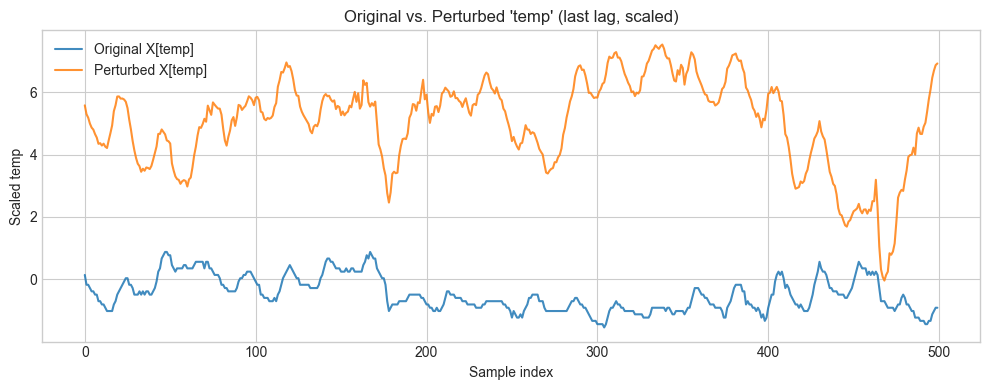

In [233]:
# Plot original vs. perturbed 'temp' feature (last lag/current step)
import numpy as np
import matplotlib.pyplot as plt

# Ensure we can build the correct column index for 'temp'
base_dim = len(feature_cols)
if 'temp' not in feature_cols:
    raise ValueError("Feature 'temp' not found in feature_cols.")

idx_temp = feature_cols.index('temp')
d = X_test.shape[1]

# If windows are flattened, pick the last lag; otherwise use the base index
if context_length is not None and d == base_dim * context_length:
    temp_idx = (context_length - 1) * base_dim + idx_temp
else:
    temp_idx = idx_temp

# Use existing X_perturbed if available, else derive it
X_pert = X_perturbed if 'X_perturbed' in globals() else (X_test + perturbations_matrix)

orig_temp = X_test[:, temp_idx]
pert_temp = X_pert[:, temp_idx]

# Plot a manageable slice
N = min(500, orig_temp.shape[0])
x = np.arange(N)

plt.figure(figsize=(10, 4))
plt.plot(x, orig_temp[:N], label="Original X[temp]", alpha=0.85)
plt.plot(x, pert_temp[:N], label="Perturbed X[temp]", alpha=0.85)
plt.title("Original vs. Perturbed 'temp' (last lag, scaled)")
plt.xlabel("Sample index")
plt.ylabel("Scaled temp")
plt.legend()
plt.tight_layout()
plt.show()

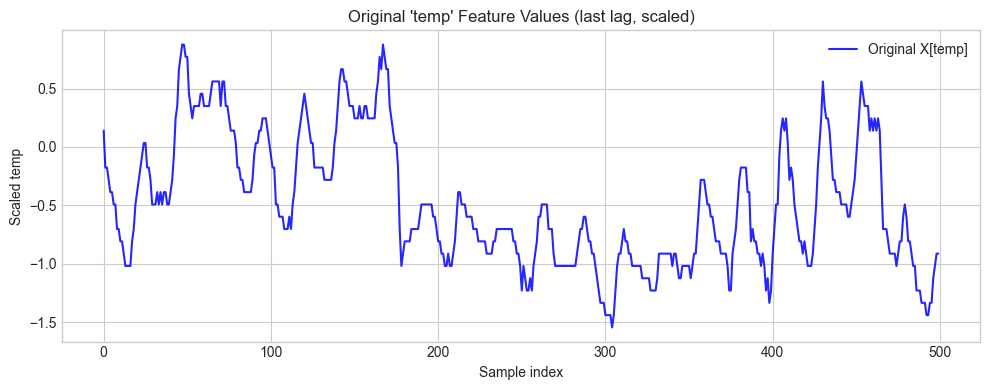

In [229]:
# plot only the original temp values
plt.figure(figsize=(10, 4))
plt.plot(x, orig_temp[:N], label="Original X[temp]", color='blue',
            alpha=0.85)
plt.title("Original 'temp' Feature Values (last lag, scaled)")
plt.xlabel("Sample index")
plt.ylabel("Scaled temp")
plt.legend()
plt.tight_layout()
plt.show()
